# 04 - Preprocessing: sampling frequency adaptation

Goal: implement the sampling-rate increase step of the pipeline. We start from `S3`, the signal after baseline and power-line cleaning, and resample it to obtain `S4`.

## Simple idea

Upsampling increases the number of samples per second. For record `a14`, the signal starts at 1000 Hz, meaning 1000 samples per second. We resample it to 2000 Hz, meaning 2000 samples per second.

This does not create new physiological information. It only places the same signal on a denser time grid, which can help the next QRS-detection steps localize peaks more precisely.

In [5]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import importlib
import matplotlib.pyplot as plt
import data_io
import preprocessing
import plotting

# Reload local modules so Jupyter picks up code changes during development.
importlib.reload(data_io)
importlib.reload(preprocessing)
importlib.reload(plotting)

from data_io import load_record
from preprocessing import remove_baseline_wander, remove_powerline_interference, upsample_signals
from plotting import plot_upsampling_zoom


## Load the record and rebuild S3

`S3` is the output of the previous preprocessing step. We rebuild it here so this notebook can run independently.

In [6]:
record = load_record('a14')
S1 = record.signals

baseline_result = remove_baseline_wander(
    S1,
    fs=record.fs,
    cutoff_hz=3.0,
    numtaps=1001,
)
S2 = baseline_result.filtered_signals

powerline_result = remove_powerline_interference(
    S2,
    fs=record.fs,
    frequencies_hz=(50.0, 100.0, 150.0),
)
S3 = powerline_result.cleaned_signals

print(f'Record: {record.name}')
print(f'S3 shape: {S3.shape}')
print(f'S3 sampling frequency: {record.fs:.0f} Hz')
print(f'S3 duration: {S3.shape[0] / record.fs:.2f} s')


Record: a14
S3 shape: (60000, 4)
S3 sampling frequency: 1000 Hz
S3 duration: 60.00 s


## Apply upsampling

We resample `S3` to 2000 Hz. The number of samples doubles, while the signal duration remains the same.

In [7]:
upsampling_result = upsample_signals(
    S3,
    fs=record.fs,
    target_fs=2000.0,
)
S4 = upsampling_result.upsampled_signals

duration_s3 = upsampling_result.original_samples / upsampling_result.original_fs
duration_s4 = upsampling_result.upsampled_samples / upsampling_result.target_fs

print(f'Original S3 signal: {upsampling_result.original_samples} samples at {upsampling_result.original_fs:.0f} Hz')
print(f'Duration S3: {duration_s3:.2f} seconds')
print(f'Upsampled S4 signal: {upsampling_result.upsampled_samples} samples at {upsampling_result.target_fs:.0f} Hz')
print(f'Duration S4: {duration_s4:.2f} seconds')
print(f'S4 shape: {S4.shape}')


Original S3 signal: 60000 samples at 1000 Hz
Duration S3: 60.00 seconds
Upsampled S4 signal: 120000 samples at 2000 Hz
Duration S4: 60.00 seconds
S4 shape: (120000, 4)


## Zoomed comparison

On a full 60-second plot, `S3` and `S4` would look almost identical. The useful difference is the sampling grid: `S4` has intermediate samples between the original `S3` samples. A short zoom makes this visible.

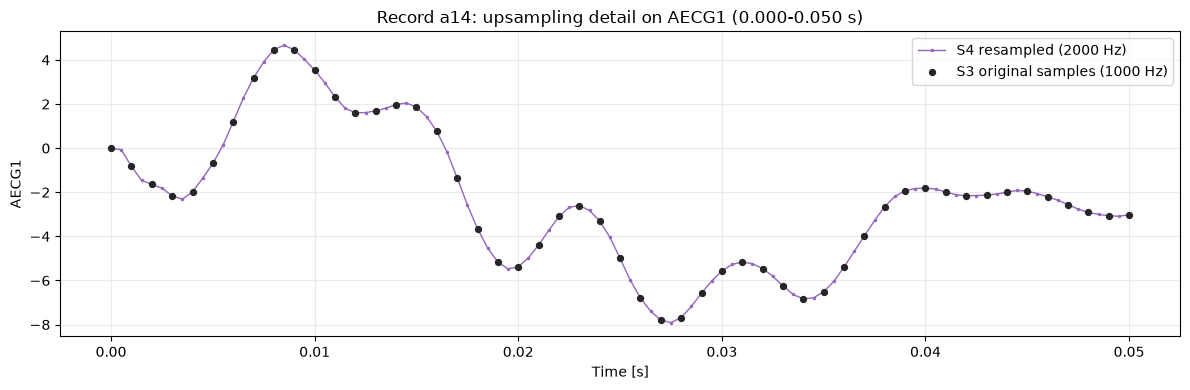

In [8]:
fig, ax = plot_upsampling_zoom(
    record,
    S3,
    S4,
    original_fs=upsampling_result.original_fs,
    target_fs=upsampling_result.target_fs,
    channel=0,
    seconds=(0, 0.05),
    save_path=PROJECT_ROOT / 'figures' / 'notebook04' / 'a14_upsampling_zoom_ch1_0_0p05s.png',
)
plt.show()


## Output of this step

`S4` is the upsampled signal. It has the same 4 channels and the same duration as `S3`, but it contains more samples. The next step is maternal QRS detection.